# Eksperimen Preprocessing BankChurners

Notebook ini digunakan untuk eksplorasi dataset BankChurners dan validasi alur preprocessing sebelum diotomatisasi pada `automate_amin.py`.

## 1. Import Library dan Load Dataset

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "preprocessing" else cwd
data_path = project_root / "BankChurners.csv"

df = pd.read_csv(data_path)
df.shape

(10127, 23)

## 2. Data Understanding

In [2]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,NaN,NaN,NaN,739177606.333663,36903783.450231,708082083.0,713036770.5,717926358.0,773143533.0,828343083.0
Attrition_Flag,10127,2,Existing Customer,8500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,10127.0,NaN,NaN,NaN,46.32596,8.016814,26.0,41.0,46.0,52.0,73.0
Gender,10127,2,F,5358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,10127.0,NaN,NaN,NaN,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
Education_Level,10127,7,Graduate,3128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,10127,4,Married,4687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,10127,6,Less than $40K,3561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,10127,4,Blue,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,10127.0,NaN,NaN,NaN,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0


## 3. Data Quality Check

In [5]:
quality_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
    "dtype": df.dtypes.astype(str),
})

quality_summary

,missing_values,missing_percent,unique_values,dtype
CLIENTNUM,0,0.0,10127,int64
Attrition_Flag,0,0.0,2,object
Customer_Age,0,0.0,45,int64
Gender,0,0.0,2,object
Dependent_count,0,0.0,6,int64
Education_Level,0,0.0,7,object
Marital_Status,0,0.0,4,object
Income_Category,0,0.0,6,object
Card_Category,0,0.0,4,object
Months_on_book,0,0.0,44,int64


In [6]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [7]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns
unknown_counts = {
    column: int((df[column] == "Unknown").sum())
    for column in categorical_columns
}

unknown_counts

{'Attrition_Flag': 0,
 'Gender': 0,
 'Education_Level': 1519,
 'Marital_Status': 749,
 'Income_Category': 1112,
 'Card_Category': 0}

## 4. Target Distribution

In [8]:
target_counts = df["Attrition_Flag"].value_counts()
target_counts

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

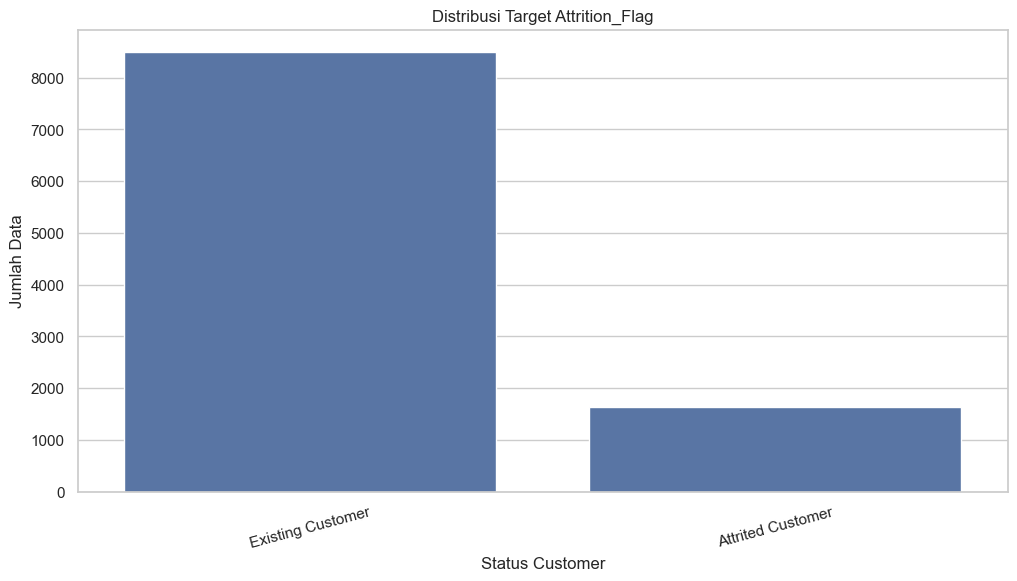

In [9]:
sns.countplot(data=df, x="Attrition_Flag")
plt.title("Distribusi Target Attrition_Flag")
plt.xlabel("Status Customer")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=15)
plt.show()

## 5. Correlation Analysis

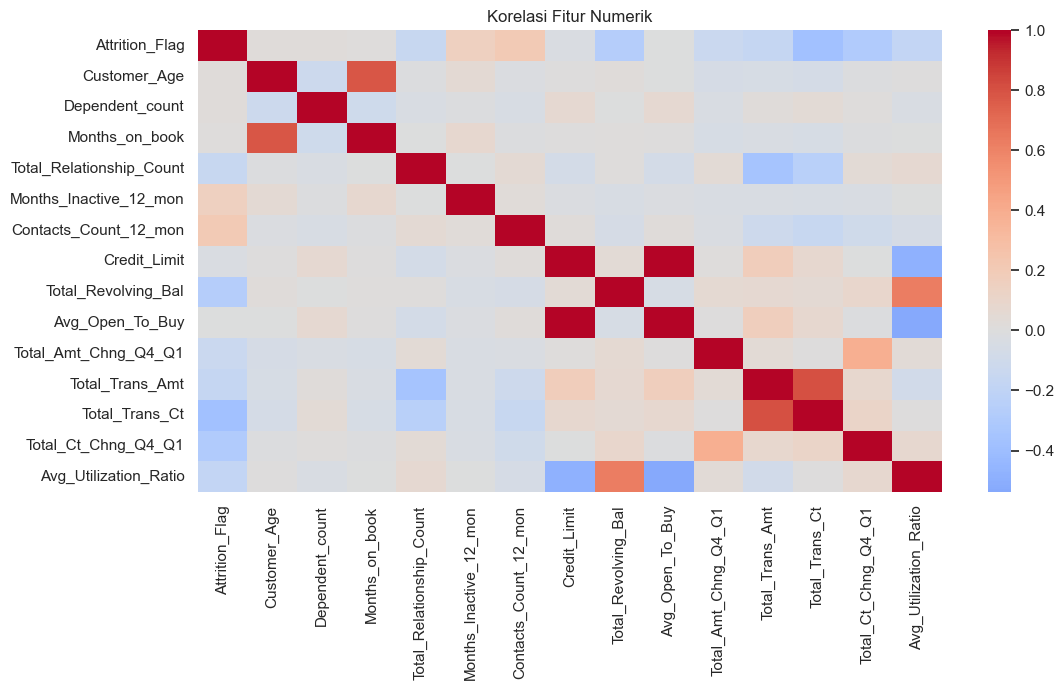

In [10]:
leakage_columns = [
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
]

corr_data = df.drop(columns=leakage_columns).copy()
corr_data["Attrition_Flag"] = corr_data["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1,
})

numeric_corr = corr_data.select_dtypes(include="number").corr()
sns.heatmap(numeric_corr, cmap="coolwarm", center=0)
plt.title("Korelasi Fitur Numerik")
plt.show()

## 6. Outlier Check

In [11]:
numeric_columns = df.drop(columns=leakage_columns).select_dtypes(include="number").columns

outlier_summary = []
for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_summary.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
    })

pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)

,column,lower_bound,upper_bound,outlier_count
6,Credit_Limit,-10213.750,23836.250,984
8,Avg_Open_To_Buy,-11477.250,22660.750,963
10,Total_Trans_Amt,-1722.750,8619.250,896
5,Contacts_Count_12_mon,0.500,4.500,629
9,Total_Amt_Chng_Q4_Q1,0.289,1.201,396
12,Total_Ct_Chng_Q4_Q1,0.228,1.172,394
2,Months_on_book,17.500,53.500,386
4,Months_Inactive_12_mon,0.500,4.500,331
0,Customer_Age,24.500,68.500,2
11,Total_Trans_Ct,-9.000,135.000,2


## 7. Eksperimen Preprocessing

Alur berikut dibuat sama dengan `automate_amin.py`: drop kolom ID/leakage, encode target, pertahankan `Unknown` sebagai kategori valid, scaling fitur numerik, lalu one-hot encoding fitur kategorikal.

In [12]:
target_column = "Attrition_Flag"
target_mapping = {
    "Existing Customer": 0,
    "Attrited Customer": 1,
}

processed = df.drop_duplicates().drop(columns=leakage_columns).copy()
processed[target_column] = processed[target_column].map(target_mapping).astype("int64")

features = processed.drop(columns=[target_column]).copy()
target = processed[target_column].copy()

categorical_features = list(features.select_dtypes(include=["object", "category"]).columns)
numeric_features = list(features.select_dtypes(include="number").columns)

features[numeric_features] = features[numeric_features].fillna(features[numeric_features].median())
features[numeric_features] = StandardScaler().fit_transform(features[numeric_features])
features[categorical_features] = features[categorical_features].fillna("Unknown")
features = pd.get_dummies(features, columns=categorical_features, dtype="int64")

processed_data = features.copy()
processed_data[target_column] = target

processed_data.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Attrition_Flag
0,-0.165406,0.503368,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,...,0,1,0,0,0,1,0,0,0,0
1,0.333570,2.043199,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,...,0,0,0,1,0,1,0,0,0,0
2,0.583058,0.503368,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,...,0,0,1,0,0,1,0,0,0,0
3,-0.789126,1.273283,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,...,0,0,0,1,0,1,0,0,0,0
4,-0.789126,0.503368,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,...,0,1,0,0,0,1,0,0,0,0


In [13]:
processed_data.shape

(10127, 38)

In [14]:
processed_data[target_column].value_counts()

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

In [15]:
processed_data.to_csv("BankChurners_preprocessing.csv", index=False)
"BankChurners_preprocessing.csv"

'BankChurners_preprocessing.csv'